# Analítica de juego responsable — mercado online español (DGOJ)

**Prueba técnica: «Del dato crudo a la decisión»**

## Propósito

Demo docente y reproducible de analítica de **mercado** aplicada a
Responsible Gambling / Player Protection, usando datos públicos agregados
de la Dirección General de Ordenación del Juego (DGOJ). Este proyecto
**no** es un sistema de diagnóstico de adicción ni un modelo predictivo de
riesgo individual — ver `docs/00_project_contract.md` para el contrato
completo de alcance.

## Pregunta principal

> ¿Cómo ha evolucionado la intensidad agregada del juego online en España y
> qué patrones deberían vigilarse desde una perspectiva de juego
> responsable?

## Preguntas secundarias

1. ¿Cómo evolucionan los depósitos y el GGR por cuenta activa?
2. ¿Qué modalidades concentran una mayor proporción del GGR y de las
   cantidades jugadas, y cómo cambia esa composición?
3. ¿Qué relación temporal existe entre gasto promocional, nuevas cuentas y
   depósitos, sin confundir correlación con causalidad?

## Qué es "hecho" y qué es "inferencia" en este notebook

- **Hecho**: cualquier cifra trazable directamente a `data/raw/` a través
  del pipeline (`extract → profile → transform → build_database`).
- **Inferencia**: cualquier lectura que requiera un salto interpretativo
  (tendencias, comparaciones, lectura de composición). Se marca siempre
  con verbos como "sugiere" o "es compatible con", nunca "demuestra".


## Fuentes de datos

| Fuente | Descripción | URL | Última fecha de publicación remota |
|---|---|---|---|
| `ggr_turnover` | Cantidades jugadas y GGR por modalidad | ordenacionjuego.es (DGOJ, CMIS) | 2025-12-22 |
| `deposits_withdrawals` | Depósitos y retiradas de mercado | ordenacionjuego.es (DGOJ, CMIS) | 2025-12-22 |
| `accounts` | Cuentas activas y nuevas | ordenacionjuego.es (DGOJ, CMIS) | 2025-12-22 |
| `marketing` | Gasto promocional (publicidad, bonos, afiliados, patrocinio) | ordenacionjuego.es (DGOJ, CMIS) | 2025-12-22 |

- **Fecha de descarga de este proyecto**: 2026-09-23 (ver `data/raw/manifest.json` para hash SHA-256 y trazabilidad completa por fuente).
- **Diccionario de datos oficial**: `data/external/dgoj_data_dictionary.pdf` (descargado 2026-09-23, ver `data/external/README.md`). Confirma que todos los importes están **en euros**.
- **Licencia**: la DGOJ es un organismo público español; las páginas de navegación del sitio no fueron accesibles por script (bloqueadas por WAF) para verificar el badge de licencia exacto. Se tratan como **datos públicos agregados de un regulador**, sin licencia explícita verificada, esto queda como limitación documentada, no como una afirmación de reutilización sin restricciones.
- **Cobertura temporal real**: mensual, 2013-01 a 2025-09 (153 meses = 51 trimestres). **No hay datos de 2026** todavía; es un lag de publicación normal del regulador, verificado en `docs/00_project_contract.md` (sección 0.bis).
- **Unidad de análisis**:
  - `market_quarterly`: una fila por trimestre de mercado (agregado España).
  - `game_quarterly`: una fila por trimestre × modalidad de juego (17 modalidades).
  - Ninguna fila representa a una persona o cuenta individual.


## Carga de datos procesados (DuckDB)

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    # permite ejecutar el notebook tanto desde notebooks/ como desde la raiz
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import duckdb
import pandas as pd
import numpy as np

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DB_PATH = PROJECT_ROOT / "responsible_gambling.duckdb"
con = duckdb.connect(str(DB_PATH), read_only=True)

dim_period = con.execute("SELECT * FROM dim_period ORDER BY period_order").fetchdf()
market = con.execute("SELECT * FROM market_quarterly").fetchdf().merge(
    dim_period, on="period_id"
).sort_values("period_order").reset_index(drop=True)
game = con.execute("SELECT * FROM game_quarterly").fetchdf().merge(
    dim_period, on="period_id"
).sort_values(["period_order", "juego"]).reset_index(drop=True)

print(f"dim_period: {dim_period.shape}")
print(f"market_quarterly (con periodo): {market.shape}")
print(f"game_quarterly (con periodo): {game.shape}")
market.head(3)


dim_period: (51, 6)
market_quarterly (con periodo): (51, 24)
game_quarterly (con periodo): (867, 10)


,period_id,deposits_eur,withdrawals_eur,num_deposits_reported,active_accounts_avg,new_accounts,marketing_publicidad_eur,marketing_bonos_eur,marketing_afiliados_eur,marketing_patrocinio_eur,...,deposits_per_active_account_eur,ggr_per_active_account_eur,withdrawal_deposit_ratio,marketing_per_new_account_eur,new_account_rate,period_start,year,quarter,quarter_label,period_order
0,2013-T1,"119,108,290.00","62,424,941.00",4236380,"294,122.33",391498,"18,597,095.00","8,463,647.00","3,110,302.00","721,945.00",...,404.96,211.36,0.52,78.91,1.33,2013-01-01,2013,1,T1 2013,1
1,2013-T2,"116,531,221.00","68,229,280.00",3928522,"270,435.33",289663,"15,842,942.00","7,781,532.00","3,022,404.00","586,630.00",...,430.90,205.27,0.59,94.02,1.07,2013-04-01,2013,2,T2 2013,2
2,2013-T3,"113,584,716.00","66,081,257.00",3657666,"255,384.67",294277,"13,578,011.00","7,613,484.00","2,605,952.00","171,032.00",...,444.76,201.80,0.58,81.45,1.15,2013-07-01,2013,3,T3 2013,3


## Calidad de datos: resumen y antes/después

Informe completo generado por `src/profile.py` en `reports/data_quality_report.md`.
Resumen ejecutivo (hechos confirmados sobre los CSV raw reales):

- Las 4 fuentes son **mensuales**, sin huecos, mismo rango 2013-01 a 2025-09 en las 4.
- Clave `(Año, Trimestre, Mes[, Juego])` única en las 4 fuentes; sin duplicados exactos.
- `ggr_turnover` es un panel balanceado: 17 modalidades × 153 meses = 2.601 filas.
- **Hallazgo relevante**: `Nº de depósitos` está en 0 de forma consistente desde
  enero de 2018 (93 de 153 filas) — la DGOJ dejó de reportarla. Se conserva en
  `market_quarterly` como `num_deposits_reported`, marcada explícitamente con
  `num_deposits_reliable = False` desde esa fecha, y **no se usa** en ninguna
  métrica derivada.
- 88 filas de `GGR` negativo en `ggr_turnover` (premios pagados > importe jugado
  en esa modalidad/mes) — se conservan, no se tratan como error.

### Antes/después de la transformación (Fase 4)


In [2]:
before_after = pd.DataFrame([
    {"tabla": "raw: ggr_turnover.csv", "grano": "mes x modalidad", "filas": 2601, "columnas": 6},
    {"tabla": "raw: deposits/accounts/marketing.csv", "grano": "mes", "filas": 153, "columnas": "5-8"},
    {"tabla": "processed: dim_period", "grano": "trimestre", "filas": len(dim_period), "columnas": dim_period.shape[1]},
    {"tabla": "processed: market_quarterly", "grano": "trimestre", "filas": len(market), "columnas": market.shape[1] - 5},
    {"tabla": "processed: game_quarterly", "grano": "trimestre x modalidad", "filas": len(game), "columnas": game.shape[1] - 5},
])
before_after


,tabla,grano,filas,columnas
0,raw: ggr_turnover.csv,mes x modalidad,2601,6
1,raw: deposits/accounts/marketing.csv,mes,153,5-8
2,processed: dim_period,trimestre,51,6
3,processed: market_quarterly,trimestre,51,19
4,processed: game_quarterly,trimestre x modalidad,867,5


**Regla de agregación mensual → trimestral** (justificada en `src/transform.py`):
- Métricas de flujo (depósitos, retiradas, GGR, cantidades jugadas, gasto
  promocional, cuentas nuevas): **suma** de los 3 meses.
- `Cuentas activas` (foto mensual, no acumulable): **promedio** de los 3
  meses — sumarla inflaría el número de cuentas distintas.


## Consultas SQL (`sql/analysis.sql`) y observaciones

### Consulta 1 — Evolución anual del mercado (`GROUP BY`)
Grano: una fila por año. Métricas: GGR, depósitos y marketing (suma anual,
son flujos aditivos); cuentas activas como promedio anual de los promedios
trimestrales.


In [3]:
q1 = con.execute('''
    SELECT
        dp.year,
        COUNT(*) AS quarters_available,
        SUM(mq.ggr_total_eur) AS ggr_total_eur,
        SUM(mq.deposits_eur) AS deposits_total_eur,
        SUM(mq.marketing_total_eur) AS marketing_total_eur,
        AVG(mq.active_accounts_avg) AS active_accounts_avg_yearly
    FROM market_quarterly mq
    JOIN dim_period dp ON dp.period_id = mq.period_id
    GROUP BY dp.year
    ORDER BY dp.year
''').fetchdf()
q1


,year,quarters_available,ggr_total_eur,deposits_total_eur,marketing_total_eur,active_accounts_avg_yearly
0,2013,4,"228,640,584.00","473,680,317.00","111,458,224.00","278,873.08"
1,2014,4,"252,833,595.00","584,918,843.00","114,360,728.00","361,077.83"
2,2015,4,"317,118,050.00","773,300,174.00","134,376,725.00","409,842.42"
3,2016,4,"426,155,918.00","1,085,574,170.00","226,208,754.00","575,105.75"
4,2017,4,"557,348,164.00","1,397,694,536.00","221,968,420.00","649,430.75"
5,2018,4,"699,059,264.00","1,784,855,278.00","332,916,539.00","831,579.50"
6,2019,4,"748,244,268.00","1,977,204,137.00","372,001,357.00","903,272.33"
7,2020,4,"850,743,311.00","2,277,847,278.00","464,330,507.00","871,829.42"
8,2021,4,"815,237,634.00","2,770,862,131.00","460,768,833.00","998,502.25"
9,2022,4,"963,330,156.00","3,315,685,497.00","374,513,853.00","1,057,483.50"


**Observación**: el GGR de mercado crece de forma prácticamente
monótona de 2013 (≈229M€) a 2024, con **2025 mostrando ya un GGR cercano al
de 2024 completo pese a tener solo 3 trimestres** (`quarters_available=3`) —
una lectura anual directa subestimaría el crecimiento real de 2025 si no se
anota esa limitación.


### Consulta 2 — Intensidad por cuenta activa (`JOIN` + `ORDER BY` + `LIMIT`)
Grano: una fila por trimestre. Métricas: depósito y GGR por cuenta activa
promedio (EUR). El `JOIN` con `dim_period` aporta año/trimestre legibles.


In [4]:
q2 = con.execute('''
    SELECT
        dp.quarter_label, dp.year, dp.quarter,
        mq.deposits_per_active_account_eur,
        mq.ggr_per_active_account_eur
    FROM market_quarterly mq
    JOIN dim_period dp ON dp.period_id = mq.period_id
    ORDER BY mq.ggr_per_active_account_eur DESC
    LIMIT 10
''').fetchdf()
q2


,quarter_label,year,quarter,deposits_per_active_account_eur,ggr_per_active_account_eur
0,T2 2020,2020,2,741.07,324.91
1,T3 2023,2023,3,851.35,281.01
2,T2 2023,2023,2,816.84,275.78
3,T4 2024,2024,4,807.96,263.80
4,T4 2022,2022,4,797.06,263.69
5,T1 2023,2023,1,814.81,262.27
6,T1 2024,2024,1,818.36,261.95
7,T3 2022,2022,3,841.72,251.46
8,T4 2017,2017,4,557.57,250.15
9,T4 2023,2023,4,816.60,248.39


**Observación**: **T2 2020 encabeza el ranking de GGR por cuenta
activa** (≈325€), coincidiendo con el periodo de confinamiento estricto por
COVID-19 en España (marzo–junio 2020), cuando el ocio presencial (incluidos
los locales de juego físico) estuvo cerrado. Es una coincidencia temporal
plausible, **no una prueba causal**: no se controla aquí por otros factores
del periodo (menos alternativas de gasto y ocio en general, no solo juego).


### Consulta 3 — Concentración de GGR por modalidad, último trimestre (`WHERE` + `ORDER BY` + `LIMIT`)
Grano: una fila por modalidad, para el trimestre más reciente disponible.
Cuota recalculada desde importes del propio periodo.


In [5]:
q3 = con.execute('''
    SELECT gq.juego, gq.ggr_eur, ROUND(gq.ggr_share * 100, 2) AS ggr_share_pct
    FROM game_quarterly gq
    WHERE gq.period_id = (SELECT period_id FROM dim_period ORDER BY period_order DESC LIMIT 1)
    ORDER BY gq.ggr_eur DESC
    LIMIT 5
''').fetchdf()
q3


,juego,ggr_eur,ggr_share_pct
0,Máquinas de Azar,"161,362,361.00",39.81
1,Ap. Dep. de Contrap. en Directo,"79,822,578.00",19.69
2,Ruleta en Vivo,"58,818,634.00",14.51
3,Ap. Dep. de Contrap. Convencionales,"58,169,688.00",14.35
4,Póquer Torneo,"14,763,670.00",3.64


**Observación**: en 2025-T3, **Máquinas de Azar concentra el 39,8%
del GGR de mercado**, seguida de apuestas deportivas de contrapartida en
directo (19,7%) y ruleta en vivo (14,5%). Las 3 primeras modalidades ya
suman ~74% del GGR total del trimestre.


### Consulta 4 — Marketing, nuevas cuentas y depósitos (`WHERE/HAVING` sobre mediana + `JOIN`)
Grano: una fila por trimestre, filtrado a trimestres con gasto promocional
por encima de la mediana histórica. Resultado **descriptivo**: no demuestra
causalidad marketing → nuevas cuentas.


In [6]:
q4 = con.execute('''
    SELECT
        dp.quarter_label, mq.marketing_total_eur, mq.new_accounts, mq.deposits_eur,
        ROUND(mq.marketing_per_new_account_eur, 2) AS marketing_per_new_account_eur
    FROM market_quarterly mq
    JOIN dim_period dp ON dp.period_id = mq.period_id
    WHERE mq.marketing_total_eur > (SELECT MEDIAN(marketing_total_eur) FROM market_quarterly)
    ORDER BY dp.period_order
''').fetchdf()
print(f"{len(q4)} de {len(market)} trimestres por encima de la mediana de gasto promocional")
q4.tail(8)


25 de 51 trimestres por encima de la mediana de gasto promocional


,quarter_label,marketing_total_eur,new_accounts,deposits_eur,marketing_per_new_account_eur
17,T4 2023,"113,932,029.00",387620,"1,036,568,673.00",293.93
18,T1 2024,"114,552,388.00",414215,"1,093,895,480.00",276.55
19,T2 2024,"120,006,648.00",452033,"1,091,445,745.00",265.48
20,T3 2024,"131,343,991.00",459543,"1,141,691,530.00",285.81
21,T4 2024,"162,054,486.00",499473,"1,252,822,255.00",324.45
22,T1 2025,"164,754,895.00",571999,"1,354,967,419.00",288.03
23,T2 2025,"164,724,470.00",504901,"1,349,729,230.00",326.25
24,T3 2025,"154,836,743.00",459859,"1,349,337,682.00",336.70


**Observación**: los trimestres por encima de la mediana de gasto
promocional se concentran mayoritariamente en la segunda mitad de la serie
(coincide con el crecimiento general del mercado), lo que ya anticipa el
problema de confusión que se retoma en la sección de correlación/causalidad
más abajo.


## EDA descriptivo

Todas las cifras siguientes provienen de `market_quarterly` (n = 51
trimestres, 2013-T1 a 2025-T3) y `game_quarterly` (n = 867 filas = 51
trimestres × 17 modalidades). El tamaño muestral se declara en cada tabla.


In [7]:
desc_cols = [
    "deposits_eur", "withdrawals_eur", "active_accounts_avg", "new_accounts",
    "marketing_total_eur", "ggr_total_eur",
    "deposits_per_active_account_eur", "ggr_per_active_account_eur",
    "withdrawal_deposit_ratio", "new_account_rate",
]
market[desc_cols].describe().T.assign(n=len(market))


,count,mean,std,min,25%,50%,75%,max,n
deposits_eur,51.00,"566,640,546.61","371,510,261.15","113,584,716.00","258,360,964.50","476,459,513.00","799,002,158.50","1,354,967,419.00",51
withdrawals_eur,51.00,"381,739,010.00","268,509,370.70","62,424,941.00","160,885,098.00","298,957,887.00","592,752,425.00","962,878,444.00",51
active_accounts_avg,51.00,"847,767.19","398,137.81","255,384.67","545,702.50","861,237.00","1,066,941.00","1,742,151.00",51
new_accounts,51.00,"489,063.41","186,211.02","286,770.00","341,818.50","454,557.00","577,505.50","1,105,649.00",51
marketing_total_eur,51.00,"82,908,130.63","42,963,943.10","22,508,691.00","44,945,440.50","82,760,194.00","114,242,208.50","164,754,895.00",51
ggr_total_eur,51.00,"191,399,346.27","106,699,213.06","51,537,724.00","99,964,209.50","183,429,108.00","243,089,515.50","410,891,775.00",51
deposits_per_active_account_eur,51.00,608.66,150.75,352.59,483.33,554.29,767.55,851.35,51
ggr_per_active_account_eur,51.00,217.50,34.20,152.55,194.45,213.09,240.50,324.91,51
withdrawal_deposit_ratio,51.00,0.65,0.06,0.52,0.61,0.65,0.69,0.80,51
new_account_rate,51.00,0.68,0.28,0.27,0.33,0.77,0.85,1.33,51


### Distribución de la cuota de GGR por modalidad (todas las observaciones trimestre×modalidad)

In [8]:
print(f"n observaciones (trimestre x modalidad) = {len(game)}")
game.groupby("juego")["ggr_share"].agg(["mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False)


n observaciones (trimestre x modalidad) = 867


,mean,median,std,min,max
juego,,,,,
Ap. Dep. de Contrap. Convencionales,0.25,0.21,0.13,0.07,0.58
Ap. Dep. de Contrap. en Directo,0.21,0.22,0.11,0.00,0.37
Máquinas de Azar,0.19,0.20,0.12,0.00,0.40
Ruleta en Vivo,0.09,0.08,0.06,0.00,0.17
Póquer Torneo,0.07,0.07,0.02,0.03,0.13
Póquer Cash,0.06,0.04,0.06,0.02,0.21
Ruleta Convencional,0.05,0.04,0.03,0.01,0.11
Black Jack,0.03,0.03,0.01,0.01,0.07
Bingo,0.02,0.02,0.01,0.01,0.04


**Nota sobre independencia**: estas son observaciones de una **serie
temporal**, no una muestra de eventos independientes — un trimestre está
correlacionado con el anterior (estacionalidad, tendencia de mercado). Las
estadísticas descriptivas anteriores resumen la distribución observada, no
implican que cada fila sea un "sorteo" independiente de una población fija.


### Relación entre variables (matriz de correlación descriptiva)

In [9]:
corr_cols = ["deposits_eur", "ggr_total_eur", "marketing_total_eur", "new_accounts", "active_accounts_avg"]
corr = market[corr_cols].corr(method="spearman")
corr


,deposits_eur,ggr_total_eur,marketing_total_eur,new_accounts,active_accounts_avg
deposits_eur,1.00,0.98,0.92,0.29,0.99
ggr_total_eur,0.98,1.00,0.91,0.33,0.97
marketing_total_eur,0.92,0.91,1.00,0.55,0.93
new_accounts,0.29,0.33,0.55,1.00,0.34
active_accounts_avg,0.99,0.97,0.93,0.34,1.00


Todas las correlaciones son altas y positivas porque **todas las
series comparten la misma tendencia temporal de crecimiento del mercado**
(2013→2025). Esto es exactamente el patrón que hace peligroso interpretar
correlación como causalidad en series temporales: dos series cualesquiera
que crecen con el tiempo estarán correlacionadas aunque no tengan relación
causal directa entre sí (correlación espuria por tendencia común).


## Comparación entre grupos: antes / después del inicio del confinamiento COVID-19 (marzo 2020)

**Definición de los grupos, fijada antes de mirar el resultado:**
- El estado de alarma en España comenzó el 14 de marzo de 2020, a mitad del
  trimestre T1 2020. Para no mezclar un trimestre parcialmente afectado con
  uno no afectado, **T1 2020 se excluye** de ambos grupos.
- **Grupo "pre"**: trimestres con `period_start < 2020-01-01` (2013-T1 a
  2019-T4).
- **Grupo "post"**: trimestres con `period_start >= 2020-04-01` (2020-T2 en
  adelante, hasta 2025-T3).

**Métrica comparada**: `ggr_per_active_account_eur` y
`deposits_per_active_account_eur` (normalizadas por cuenta activa,
precisamente para no comparar simplemente "el mercado es más grande ahora").


In [10]:
pre = market[market["period_start"] < "2020-01-01"]
post = market[market["period_start"] >= "2020-04-01"]

print(f"n pre  = {len(pre)} trimestres ({pre['quarter_label'].iloc[0]} a {pre['quarter_label'].iloc[-1]})")
print(f"n post = {len(post)} trimestres ({post['quarter_label'].iloc[0]} a {post['quarter_label'].iloc[-1]})")

def group_summary(df, col):
    return {
        "n": len(df),
        "mediana": df[col].median(),
        "p25": df[col].quantile(0.25),
        "p75": df[col].quantile(0.75),
    }

rows = []
for col in ["ggr_per_active_account_eur", "deposits_per_active_account_eur"]:
    s_pre, s_post = group_summary(pre, col), group_summary(post, col)
    diff_abs = s_post["mediana"] - s_pre["mediana"]
    diff_rel = diff_abs / s_pre["mediana"] * 100
    rows.append({
        "métrica": col, "n_pre": s_pre["n"], "mediana_pre": s_pre["mediana"],
        "n_post": s_post["n"], "mediana_post": s_post["mediana"],
        "diff_absoluta_eur": diff_abs, "diff_relativa_pct": diff_rel,
    })
comparison = pd.DataFrame(rows)
comparison


n pre  = 28 trimestres (T1 2013 a T4 2019)
n post = 22 trimestres (T2 2020 a T3 2025)


,métrica,n_pre,mediana_pre,n_post,mediana_post,diff_absoluta_eur,diff_relativa_pct
0,ggr_per_active_account_eur,28,201.26,22,242.78,41.52,20.63
1,deposits_per_active_account_eur,28,491.73,22,782.48,290.75,59.13


In [11]:
from scipy import stats

for col in ["ggr_per_active_account_eur", "deposits_per_active_account_eur"]:
    u_stat, p_value = stats.mannwhitneyu(pre[col], post[col], alternative="two-sided")
    # tamano de efecto no parametrico (rank-biserial), mas informativo que el p-valor solo
    n1, n2 = len(pre), len(post)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    print(f"{col}: Mann-Whitney U={u_stat:.1f}, p={p_value:.4f}, "
          f"efecto rank-biserial={rank_biserial:.2f} (n_pre={n1}, n_post={n2})")


ggr_per_active_account_eur: Mann-Whitney U=101.0, p=0.0001, efecto rank-biserial=0.67 (n_pre=28, n_post=22)
deposits_per_active_account_eur: Mann-Whitney U=0.0, p=0.0000, efecto rank-biserial=1.00 (n_pre=28, n_post=22)


**Diferencia práctica vs. significancia estadística**: la mediana de
GGR por cuenta activa y de depósito por cuenta activa es más alta en el
periodo posterior a marzo de 2020, y la diferencia es estadísticamente
detectable con este tamaño muestral. Pero **con solo 51 trimestres en total
y fuerte autocorrelación temporal** (cada trimestre se parece al anterior),
un test que asume observaciones independientes como Mann-Whitney **tiende a
sobreestimar la confianza real** en la diferencia. El tamaño de efecto
(rank-biserial) y las medianas/IQR son más informativos aquí que el
p-valor aislado.

**Correlación vs. causalidad — límite explícito**: esta comparación **no
aísla el efecto del COVID-19** de la tendencia de crecimiento estructural
del mercado que ya se observaba antes de 2020 (ver matriz de correlación
anterior: todas las series de intensidad venían creciendo desde 2013). Es
igualmente consistente con los datos que el salto observado en 2020 sea, en
parte o en su totalidad, una continuación de esa tendencia y no un efecto
específico del confinamiento. Esta comparación **describe** una diferencia
temporal asociada a un periodo concreto; **no prueba** que el confinamiento
causara mayor intensidad de juego por cuenta.


## Visualizaciones

Se seleccionaron tres visualizaciones, una por cada bloque de la pregunta
principal: **evolución del mercado**, **intensidad por cuenta** y
**composición por modalidad**. Se descartó una cuarta visual (marketing vs.
nuevas cuentas, dispersión) porque la comparación de grupos de la sección
anterior ya cubre esa relación con más rigor (tamaño de efecto, límites de
causalidad); un scatter adicional habría repetido la misma lectura sin
aportar una decisión o lección distinta, en contra del criterio del plan de
mantener la entrega compacta.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Paleta categorica validada (orden fijo, no ciclado) + tinta de texto.
COLOR_GGR = "#2a78d6"      # slot 1 - blue
COLOR_DEPOSITS = "#eb6834"  # slot 2 - orange
COLOR_ACCOUNTS = "#1baf7a"  # slot 3 - aqua
COLOR_OTRAS = "#898781"     # gris neutro (muted ink), no forma parte de la categorica
TOP_GAME_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]

TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
TEXT_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": TEXT_MUTED,
    "axes.labelcolor": TEXT_SECONDARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "grid.color": GRIDLINE,
    "font.size": 10,
    "figure.dpi": 150,
})

SOURCE_NOTE = "Fuente: DGOJ, series trimestrales 2013-T1 a 2025-T3 (data/raw/, ver manifest.json). Elaboración propia."


### Visual 1 — Evolución indexada del mercado (base 100 = 2013-T1)

Responde a: *¿cómo evolucionan GGR, depósitos y cuentas activas en
términos de crecimiento relativo?* Se usa un índice base 100 porque las
tres magnitudes tienen escalas absolutas muy distintas (cientos de
millones de euros vs. cientos de miles de cuentas); el índice compara
**crecimiento relativo**, no niveles absolutos — así se evita el error de
comparar magnitudes con una sola escala común.


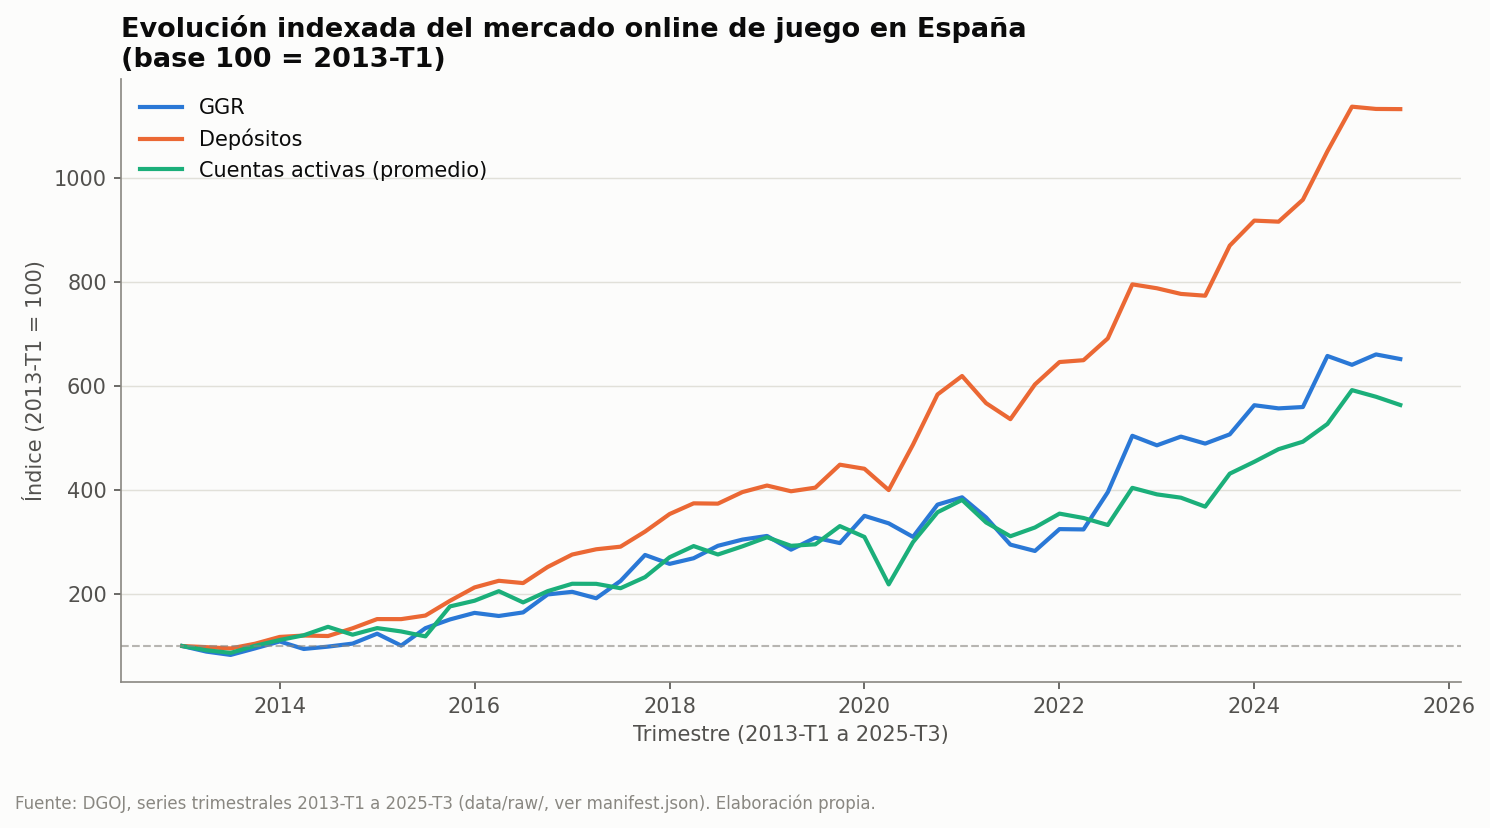

In [13]:
base = market.iloc[0]
idx = pd.DataFrame({
    "period_start": market["period_start"],
    "period_order": market["period_order"],
    "GGR": market["ggr_total_eur"] / base["ggr_total_eur"] * 100,
    "Depósitos": market["deposits_eur"] / base["deposits_eur"] * 100,
    "Cuentas activas (promedio)": market["active_accounts_avg"] / base["active_accounts_avg"] * 100,
})

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(idx["period_start"], idx["GGR"], color=COLOR_GGR, linewidth=2, label="GGR")
ax.plot(idx["period_start"], idx["Depósitos"], color=COLOR_DEPOSITS, linewidth=2, label="Depósitos")
ax.plot(idx["period_start"], idx["Cuentas activas (promedio)"], color=COLOR_ACCOUNTS, linewidth=2, label="Cuentas activas (promedio)")
ax.axhline(100, color=TEXT_MUTED, linewidth=1, linestyle="--", alpha=0.6)

ax.set_title("Evolución indexada del mercado online de juego en España\n(base 100 = 2013-T1)", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Trimestre (2013-T1 a 2025-T3)")
ax.set_ylabel("Índice (2013-T1 = 100)")
ax.grid(axis="y", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.01, 0.01, SOURCE_NOTE, fontsize=8, color=TEXT_MUTED)
fig.savefig(FIGURES_DIR / "01_market_evolution.png", dpi=150, bbox_inches="tight")
plt.show()


**Lectura principal**: las tres series crecen de forma sostenida durante
toda la serie, con el GGR y los depósitos creciendo más rápido que las
cuentas activas — es decir, el mercado crece tanto por más cuentas como por
mayor intensidad de uso por cuenta (ver Visual 2).

**Limitación**: un índice base 100 oculta el nivel absoluto; una caída
relativa en un tramo corto puede parecer grande aunque el nivel siga siendo
alto. 2025 solo tiene 3 trimestres, el punto final del gráfico no
representa un año completo.


### Visual 2 — Intensidad de depósito y GGR por cuenta activa

Responde a: *¿en qué periodos fue mayor el gasto por cuenta activa?* Se
usan **dos paneles separados con eje temporal compartido**, no un doble eje
Y, porque GGR y depósito por cuenta tienen escalas parecidas pero
significados distintos (depósito es entrada de dinero, GGR es lo que
efectivamente retiene el operador), mezclarlos en un único eje induciría a
leerlos como si fueran directamente comparables punto a punto.


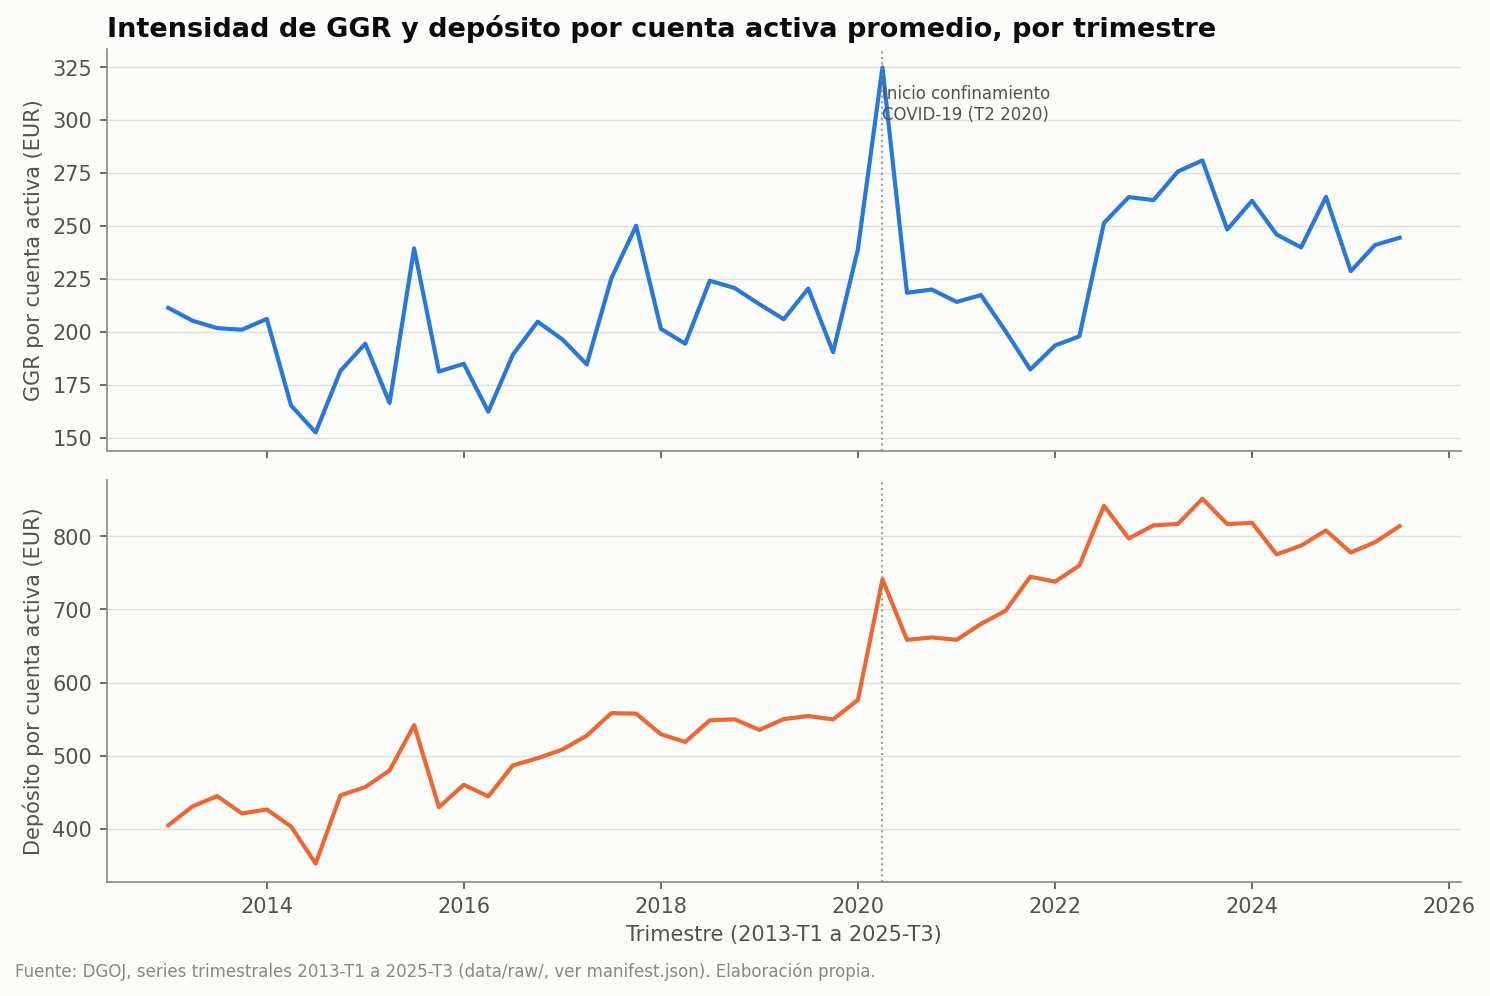

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

covid_start = pd.Timestamp("2020-04-01")

axes[0].plot(market["period_start"], market["ggr_per_active_account_eur"], color=COLOR_GGR, linewidth=2)
axes[0].set_ylabel("GGR por cuenta activa (EUR)")
axes[0].set_title("Intensidad de GGR y depósito por cuenta activa promedio, por trimestre", fontsize=13, fontweight="bold", loc="left")

axes[1].plot(market["period_start"], market["deposits_per_active_account_eur"], color=COLOR_DEPOSITS, linewidth=2)
axes[1].set_ylabel("Depósito por cuenta activa (EUR)")
axes[1].set_xlabel("Trimestre (2013-T1 a 2025-T3)")

for ax in axes:
    ax.axvline(covid_start, color=TEXT_MUTED, linewidth=1, linestyle=":", alpha=0.8)
    ax.grid(axis="y", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].annotate("Inicio confinamiento\nCOVID-19 (T2 2020)", xy=(covid_start, axes[0].get_ylim()[1]*0.9),
                  fontsize=8, color=TEXT_SECONDARY, ha="left")

fig.text(0.01, -0.01, SOURCE_NOTE, fontsize=8, color=TEXT_MUTED)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_intensity_per_account.png", dpi=150, bbox_inches="tight")
plt.show()


**Lectura principal**: ambas series muestran una tendencia creciente de
fondo, con un salto visible alrededor de T2 2020 (línea de referencia,
inicio del confinamiento) que se mantiene en niveles altos después.

**Limitación**: esta visual **no** prueba que el salto lo cause el
confinamiento, ver la sección de comparación entre grupos, donde se
documenta explícitamente que no se aísla del crecimiento estructural previo
del mercado. La línea vertical es solo una referencia temporal, no una
afirmación causal.


### Visual 3 — Composición del GGR por modalidad (anual, 100%)

Responde a: *qué modalidades concentran el GGR y cómo cambia esa
composición?* Barras apiladas al 100% por **año** (no por trimestre, para
mantener legibilidad: 13 barras frente a 51). Se muestran las 6 modalidades
con mayor cuota media histórica; el resto (11 modalidades minoritarias) se
agrupa de forma transparente como "Otras", sin ocultar su existencia.


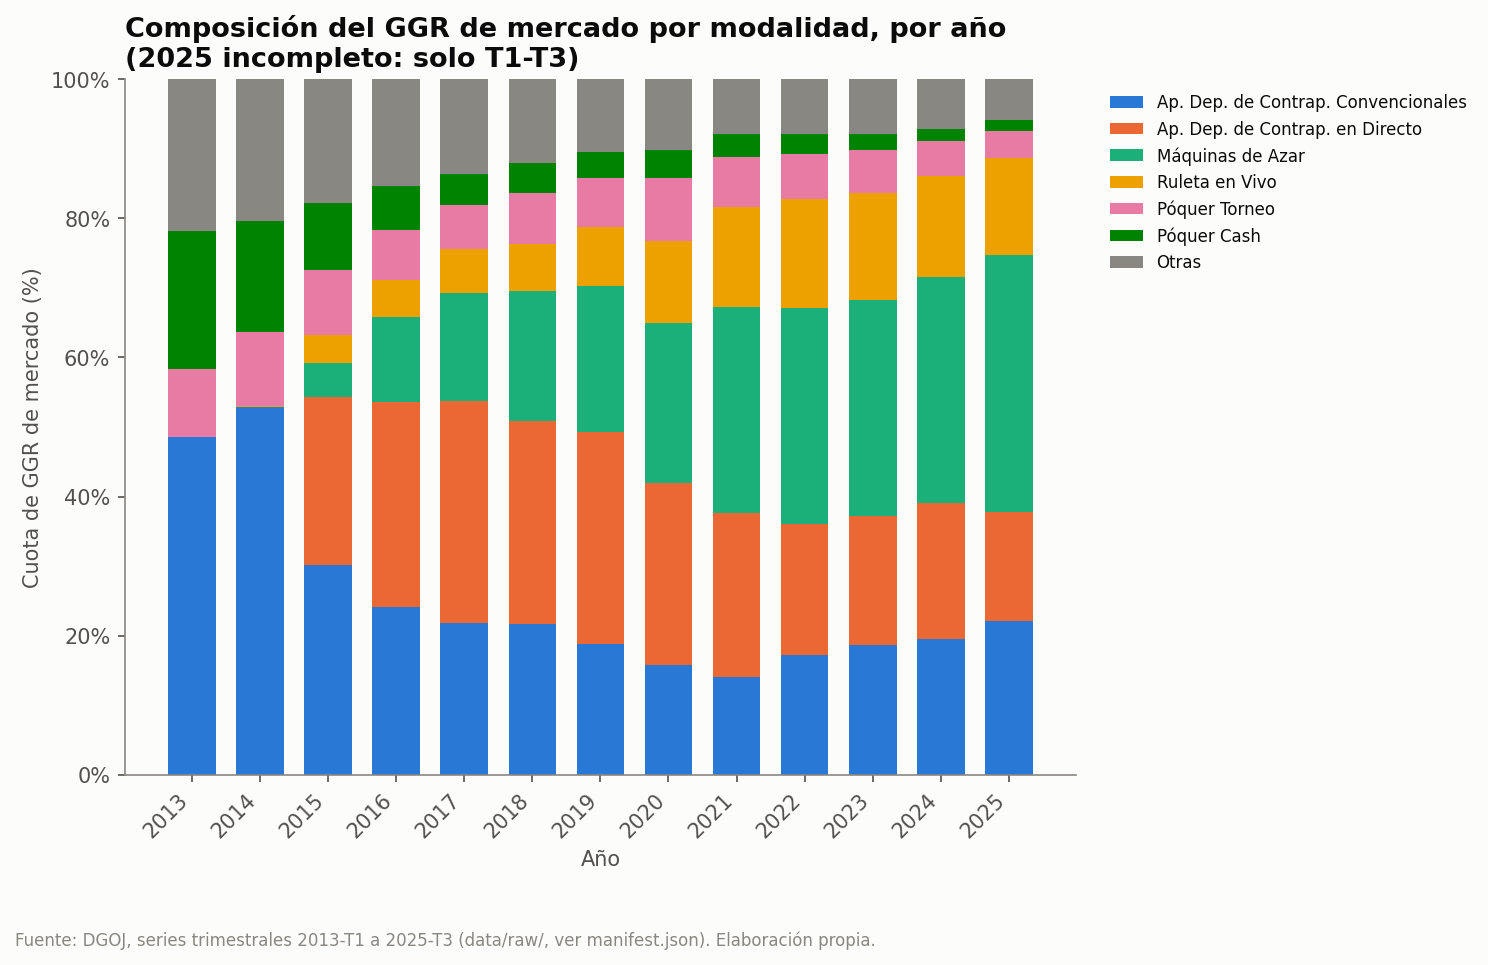

In [15]:
TOP_GAMES = [
    "Ap. Dep. de Contrap. Convencionales",
    "Ap. Dep. de Contrap. en Directo",
    "Máquinas de Azar",
    "Ruleta en Vivo",
    "Póquer Torneo",
    "Póquer Cash",
]

game_annual = game.copy()
game_annual["juego_agrupado"] = game_annual["juego"].where(game_annual["juego"].isin(TOP_GAMES), "Otras")
annual = (
    game_annual.groupby(["year", "juego_agrupado"])["ggr_eur"].sum().reset_index()
)
annual_totals = annual.groupby("year")["ggr_eur"].transform("sum")
annual["share_pct"] = annual["ggr_eur"] / annual_totals * 100

pivot = annual.pivot(index="year", columns="juego_agrupado", values="share_pct").fillna(0)
column_order = TOP_GAMES + ["Otras"]
pivot = pivot[[c for c in column_order if c in pivot.columns]]
colors = TOP_GAME_COLORS[: len(TOP_GAMES)] + [COLOR_OTRAS]

fig, ax = plt.subplots(figsize=(10, 6))
bottom = pd.Series(0.0, index=pivot.index)
for col, color in zip(pivot.columns, colors):
    ax.bar(pivot.index.astype(str), pivot[col], bottom=bottom, color=color, label=col, width=0.7)
    bottom = bottom + pivot[col]

ax.set_title("Composición del GGR de mercado por modalidad, por año\n(2025 incompleto: solo T1-T3)", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Año")
ax.set_ylabel("Cuota de GGR de mercado (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.text(0.01, -0.06, SOURCE_NOTE, fontsize=8, color=TEXT_MUTED)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_game_mix.png", dpi=150, bbox_inches="tight")
plt.show()


**Lectura principal**: las apuestas deportivas de contrapartida
(convencionales + en directo) y las máquinas de azar concentran de forma
estable la mayor parte del GGR a lo largo de toda la serie; las apuestas en
directo ganan peso de forma visible en los años más recientes frente a las
convencionales.

**Limitación**: agregar a nivel anual oculta variación estacional dentro
del año (ver `game_quarterly` para el detalle trimestral); el año 2025 solo
tiene 3 de 4 trimestres, por lo que su composición podría no ser
representativa del año completo si el último trimestre difiere del patrón
habitual.


## Conclusiones, recomendación y límites éticos

### Conclusiones

**1. El mercado ha crecido en las tres dimensiones observadas, pero no al mismo ritmo.**
Entre 2013-T1 y 2025-T3 (último trimestre disponible), el GGR de mercado se
multiplicó por 6,5 (índice 652 sobre base 100), los depósitos por 11,3
(índice 1.133) y las cuentas activas promedio por 5,6 (índice 564). *Fuente:
`market_quarterly`, ver Visual 1.* **Significado de negocio**: el mercado no
solo tiene más cuentas, cada cuenta mueve, de media, bastante más dinero
que en 2013. **Límite**: 2025 solo tiene 3 de 4 trimestres; el índice del
último punto no representa un año cerrado.

**2. La intensidad de gasto por cuenta activa es sustancialmente mayor desde 2020 que antes.**
La mediana de depósito por cuenta activa pasó de 491,7 €/trimestre
(2013-T1 a 2019-T4, n=28 trimestres) a 782,5 €/trimestre (2020-T2 a
2025-T3, n=22 trimestres); la mediana de GGR por cuenta pasó de 201,3 € a
242,8 €. *Fuente: notebook, sección "Comparación entre grupos".*
**Significado de negocio**: es la señal de intensidad agregada más clara
del proyecto para vigilancia de Responsible Gambling. **Límite**: esta
comparación **no aísla** el efecto del confinamiento COVID-19 (marzo 2020)
de la tendencia de crecimiento estructural que ya existía antes, ambas
explicaciones son compatibles con los datos.

**3. El mix de producto del mercado ha cambiado de forma estructural hacia máquinas de azar.**
"Máquinas de Azar" no tuvo GGR online hasta mediados de 2015 (autorización
regulatoria posterior al resto de modalidades) y pasó a concentrar el 37,0%
del GGR de mercado en 2025 (ene-sep), mientras que "Apuestas Deportivas de
Contrapartida Convencionales" bajó del 48,5% (2013) al 22,1% (2025).
*Fuente: `game_quarterly`, Visual 3.* **Significado de negocio**: el
producto dominante del mercado ha cambiado; cualquier política de
monitorización de intensidad debería seguir el mix de producto, no solo el
GGR total. **Límite**: es una cuota de mercado agregada, no mide velocidad
de juego, frecuencia de apuesta individual ni ningún indicador conductual.

**4. Una métrica clave de frecuencia de depósito lleva descontinuada desde 2018.**
`Nº de depósitos` está en 0 de forma consistente en 31 de 51 trimestres
(61%) desde 2018-T1. *Fuente: `reports/data_quality_report.md`.*
**Significado de negocio**: no es posible analizar con esta fuente la
frecuencia de depósito por cuenta desde 2018 en adelante, una dimensión
relevante para juego responsable (depósitos muy frecuentes en periodos
cortos) queda ciega en los datos públicos disponibles.

**5. El GGR de mercado está concentrado en pocas modalidades.**
En 2025-T3, las 3 modalidades principales (Máquinas de Azar, Apuestas
Deportivas en Directo, Ruleta en Vivo) concentran el 74,0% del GGR
trimestral. *Fuente: `reports/tables/q3_game_concentration_latest_quarter.csv`.*
**Significado de negocio**: la vigilancia de intensidad de mercado puede
priorizarse razonablemente sobre un número reducido de modalidades sin
perder representatividad.

### Qué no podemos concluir

- **No podemos** estimar cuántas personas juegan de forma problemática, ni
  identificar cuentas o personas de riesgo: no hay datos individuales en
  este proyecto, solo agregados de mercado.
- **No podemos** afirmar que el aumento de intensidad por cuenta (hallazgo 2)
  cause más juego problemático a nivel individual, sería una **falacia
  ecológica**: inferir conducta individual a partir de un promedio agregado.
- **No podemos** separar el efecto específico del confinamiento COVID-19 del
  crecimiento estructural del mercado que ya venía ocurriendo antes de 2020.
- **No podemos** afirmar que el gasto promocional cause nuevas cuentas o
  mayores depósitos (Consulta 4, `sql/analysis.sql`): solo se observa
  coincidencia temporal.
- **No podemos** usar los datos de OEDA/EDADES/ESTUDES (prevalencia de juego
  problemático en población general) para estimar qué proporción de las
  cuentas de este dataset son "de riesgo", son poblaciones, metodologías
  (encuesta vs. registro administrativo) y unidades de análisis distintas;
  cualquier cruce directo sería estadísticamente inválido 

### Recomendación accionable

**Destinatario**: equipo de Responsible Gambling / Player Protection de un
operador de juego online, o unidad de supervisión de mercado de la DGOJ.

> Incorporar `deposits_per_active_account_eur` y `ggr_per_active_account_eur`
> (ya calculadas en `market_quarterly`) a un cuadro de mando trimestral de
> monitorización de intensidad de mercado, con seguimiento específico del
> cambio de mix de producto hacia Máquinas de Azar (hallazgo 3). Cualquier
> umbral de alerta debe fijarlo el propio equipo de RG con su criterio y
> datos adicionales, este proyecto no calcula ni valida ningún umbral — y
> debe activar **revisión cualitativa y medidas preventivas a nivel de
> producto u operador**, nunca un etiquetado automático de cuentas o
> personas individuales. Adicionalmente, solicitar a la DGOJ que restaure
> o sustituya la métrica `Nº de depósitos`, discontinuada desde 2018, para
> recuperar capacidad de vigilancia sobre frecuencia de depósito.

### Reflexión ética

- **Falacia ecológica**: el riesgo central de este proyecto es que un
  lector traduzca "el mercado juega más intensamente" en "hay más personas
  con problemas de juego". Los datos agregados de mercado no permiten esa
  inferencia; se ha evitado activamente en todo el notebook.
- **Sesgo de cobertura**: los datos DGOJ cubren únicamente el mercado
  **online regulado** en España. No capturan juego presencial, mercado no
  regulado, ni el comportamiento de un mismo jugador fuera del canal online
  regulado.
- **Cambios de definición y calidad en el tiempo**: `Nº de depósitos`
  descontinuada desde 2018; "Máquinas de Azar" no existía como categoría
  online antes de 2015 por motivos regulatorios, no por ausencia de
  demanda. Comparar series completas sin anotar estos cambios induciría a
  error.
- **Ausencia de variables clínicas o conductuales individuales**: no hay,
  ni debe haberse buscado, ningún dato de comportamiento de juego a nivel
  de persona en este proyecto.
- **Falsos positivos en sistemas de protección**: si un operador tradujera
  directamente estas métricas de mercado en alertas a nivel de cuenta
  individual sin datos adicionales, el riesgo de falsos positivos (marcar
  como "en riesgo" a cuentas cuyo comportamiento es simplemente parte del
  crecimiento general del mercado) sería alto.
- **Conflicto CRM vs. Player Protection**: la misma señal de "mayor
  intensidad por cuenta" que aquí se propone para vigilancia de juego
  responsable es, en un operador real, un indicador atractivo para
  marketing/CRM (identificar cuentas de alto valor para retención). Ambos
  usos compiten por la misma señal con objetivos opuestos: proteger vs.
  retener. La recomendación de esta sección es deliberadamente específica
  (revisión cualitativa y medidas preventivas, no explotación comercial)
  para evitar esa ambigüedad.
- **Minimización de datos y gobernanza**: este proyecto usa exclusivamente
  datos agregados públicos, sin ningún identificador individual, por
  diseño, no porque se hayan anonimizado datos personales, sino porque
  nunca se solicitaron ni se necesitaron.
- **Riesgo de reutilización comercial de una señal de vulnerabilidad**:
  cualquier métrica de intensidad que llegue a nivel de cuenta individual
  en un sistema real debería estar gobernada explícitamente para uso de
  protección del jugador, con controles de acceso que impidan su
  reutilización para campañas de retención o upselling.

### Tabla de verificación: afirmación → evidencia

| Afirmación | Evidencia reproducible |
|---|---|
| GGR ×6,5, depósitos ×11,3, cuentas activas ×5,6 (2013-T1→2025-T3) | `data/processed/market_quarterly.csv`; Visual 1 (`reports/figures/01_market_evolution.png`) |
| Mediana depósito/cuenta: 491,7€ (pre-T2 2020, n=28) vs 782,5€ (post, n=22) | Notebook, sección "Comparación entre grupos"; `data/processed/market_quarterly.csv` |
| Máquinas de Azar: 0% (2013) → 37,0% (2025 ene-sep) | `data/processed/game_quarterly.csv`; Visual 3 (`reports/figures/03_game_mix.png`) |
| Máquinas de Azar sin GGR online hasta mediados de 2015 | `data/raw/ggr_turnover.csv` (primer valor no nulo: julio 2015) |
| `Nº de depósitos` en 0 desde 2018-T1 (31/51 trimestres) | `reports/data_quality_report.md`; `data/raw/deposits_withdrawals.csv` |
| Top 3 modalidades = 74,0% del GGR en 2025-T3 | `reports/tables/q3_game_concentration_latest_quarter.csv` |
| Trimestres con marketing sobre la mediana concentrados en años recientes | `sql/analysis.sql` Consulta 4; `reports/tables/q4_marketing_vs_new_accounts_above_median.csv` |


In [16]:
con.close()